# Notebook 1: Data Cleaning and Preprocessing

This notebook focuses on cleaning the raw drilling dataset exported from PostgreSQL. The objective is to prepare a high-quality dataset suitable for exploratory data analysis and machine learning.

In [27]:
!nvidia-smi

Tue Aug 11 06:23:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Import Required Libraries

This section imports all the Python libraries required for data manipulation, visualization, and preprocessing.

In [28]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [29]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Load the Dataset

The drilling dataset exported from PostgreSQL is loaded into a Pandas DataFrame for preprocessing.

In [30]:
import os

print(os.listdir("/content/drive"))

['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']


In [31]:
print(os.listdir("/content/drive/MyDrive"))

[' Real Time Drilling Analysis with ML', 'Hc verma', 'Class 12 Maths Ncert', 'RG Sir notes', 'Cs.gdoc', 'Study attendance.gsheet', 'Jee', 'Untitled document (3).gdoc', 'Movie ', 'Gmail - Transaction Response.pdf', 'DATA SCIENCE_(058D1 II sem students list).gsheet', '2DS_C_APAAR ID(APAAR ID).xlsx', 'Untitled document (2).gdoc', 'Smp Research Paper.gdoc', 'Research paper for Smp.gdoc', 'Solve all.gdoc', '1.png', 'Untitled document (1).gdoc', 'Google AI Studio', 'Testing\n- Unit Testing\n\n- Integration Testing\n\n-....gsheet', 'Challenges Faced\nDescribe technical or team-relat... (1).gsheet', 'Challenges Faced\nDescribe technical or team-relat....gsheet', 'Is it possible to  make the answers a bit longer (1).gsheet', 'Is it possible to  make the answers a bit longer.gsheet', 'L22 TO 26 - TALENT ACQUISITION AND MANAGEMENT.ppsx', 'Untitled presentation (3).gslides', 'Module 4.gdoc', 'Untitled presentation (2).gslides', 'Colab Notebooks', '2. TVM and Cash Flow Diagrams.pptx', '2-Time Value

In [32]:
for root, dirs, files in os.walk("/content/drive"):
    print(root)
    if root.count("/") >= 4:
        dirs[:] = []

/content/drive
/content/drive/MyDrive
/content/drive/MyDrive/ Real Time Drilling Analysis with ML
/content/drive/MyDrive/Hc verma
/content/drive/MyDrive/Class 12 Maths Ncert
/content/drive/MyDrive/RG Sir notes
/content/drive/MyDrive/Jee
/content/drive/MyDrive/Movie 
/content/drive/MyDrive/Google AI Studio
/content/drive/MyDrive/Colab Notebooks
/content/drive/.shortcut-targets-by-id
/content/drive/.Trash-0
/content/drive/.Trash-0/files
/content/drive/.Trash-0/info
/content/drive/.Encrypted
/content/drive/.Encrypted/MyDrive
/content/drive/.Encrypted/.shortcut-targets-by-id


In [33]:
import os

matches = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file == "drilling_data_cleaned.csv":
            matches.append(os.path.join(root, file))

print("Found:", len(matches))

for path in matches:
    print(path)

Found: 2
/content/drive/MyDrive/ Real Time Drilling Analysis with ML/datasets/drilling_data_cleaned.csv
/content/drive/MyDrive/Colab Notebooks/drilling_data_cleaned.csv


In [34]:
import pandas as pd

csv_path = "/content/drive/MyDrive/ Real Time Drilling Analysis with ML/datasets/drilling_data_cleaned.csv"

df = pd.read_csv(csv_path)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.head())

Rows: 598709
Columns: 37
   block_position  weight_on_bit   hookload  slips_set  rop_depth_hour  \
0        43.55661      46.948985  123.68008        0.0             0.0   
1        43.55661      46.948985  123.68008        0.0             0.0   
2        43.55661      46.948985  123.68008        0.0             0.0   
3        43.55661      46.948985  123.68008        0.0             0.0   
4        43.55661      46.948985  123.68008        0.0             0.0   

   on_bottom  top_drive_rpm  top_drive_torque_ft_lbs   flow_in  pump_pressure  \
0        0.0        0.31182                      0.0  57.19964       40.23666   
1        0.0        0.31182                      0.0  57.19964       40.23666   
2        0.0        0.31182                      0.0  57.19964       40.23666   
3        0.0        0.31182                      0.0   0.00000       40.23666   
4        0.0        0.31182                      0.0   0.00000       40.23666   

   ...  depth_hole_tvd  differential_pressu

## 3. Dataset Overview

This section provides a basic understanding of the dataset, including its dimensions, column names, data types, and descriptive statistics.

In [35]:
print("="*60)
print("DRILLING DATASET OVERVIEW")
print("="*60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nColumn Names\n")
print(df.columns.tolist())

DRILLING DATASET OVERVIEW
Rows    : 598709
Columns : 37

Column Names

['block_position', 'weight_on_bit', 'hookload', 'slips_set', 'rop_depth_hour', 'on_bottom', 'top_drive_rpm', 'top_drive_torque_ft_lbs', 'flow_in', 'pump_pressure', 'spm_total', 'pit_volume_active', 'pit_gl_active', 'gas_total_units', 'trip_volume_active', 'trip_gl', 'return_flow', 'rig_mode', 'rockit_on_off', 'mwd_inclination', 'mwd_azimuth', 'mud_temp', 'h2s_01', 'rig_event_code', 'total_depth', 'bit_diameter', 'bit_rpm', 'depth_hole_tvd', 'differential_pressure', 'downhole_torque', 'drill_mode', 'year', 'month', 'day', 'hour', 'day_of_week', 'timestamp']


In [36]:
df.head()

,block_position,weight_on_bit,hookload,slips_set,rop_depth_hour,on_bottom,top_drive_rpm,top_drive_torque_ft_lbs,flow_in,pump_pressure,...,depth_hole_tvd,differential_pressure,downhole_torque,drill_mode,year,month,day,hour,day_of_week,timestamp
0,43.55661,46.948985,123.68008,0.0,0.0,0.0,0.31182,0.0,57.19964,40.23666,...,7389.89,-531.16685,1894.27245,0.0,2020,10,25,12,6,2020-10-25 12:00:00
1,43.55661,46.948985,123.68008,0.0,0.0,0.0,0.31182,0.0,57.19964,40.23666,...,7389.89,-531.16685,1894.27245,0.0,2020,10,25,12,6,2020-10-25 12:00:00
2,43.55661,46.948985,123.68008,0.0,0.0,0.0,0.31182,0.0,57.19964,40.23666,...,7389.89,-531.16685,1894.27245,0.0,2020,10,25,12,6,2020-10-25 12:00:00
3,43.55661,46.948985,123.68008,0.0,0.0,0.0,0.31182,0.0,0.00000,40.23666,...,7389.89,-531.16685,1894.27245,0.0,2020,10,25,12,6,2020-10-25 12:00:00
4,43.55661,46.948985,123.68008,0.0,0.0,0.0,0.31182,0.0,0.00000,40.23666,...,7389.89,-531.16685,1894.27245,0.0,2020,10,25,12,6,2020-10-25 12:00:00


In [37]:
df.tail()

,block_position,weight_on_bit,hookload,slips_set,rop_depth_hour,on_bottom,top_drive_rpm,top_drive_torque_ft_lbs,flow_in,pump_pressure,...,depth_hole_tvd,differential_pressure,downhole_torque,drill_mode,year,month,day,hour,day_of_week,timestamp
598704,34.61750,2.33120,148.07481,0.0,0.0,0.0,68.86269,2993.5012,327.17447,2114.8032,...,10987.0,355.49527,3683.7420,0.0,2021,1,5,11,1,2021-01-05 11:00:00
598705,34.61749,2.33572,148.41600,0.0,0.0,0.0,68.72180,3023.8740,326.56180,2109.2493,...,10987.0,356.43910,3693.8347,0.0,2021,1,5,11,1,2021-01-05 11:00:00
598706,34.61749,2.33487,148.67189,0.0,0.0,0.0,68.88281,3222.3090,327.17447,2110.4705,...,10987.0,355.76685,3688.3015,0.0,2021,1,5,11,1,2021-01-05 11:00:00
598707,34.61749,2.35398,148.11746,0.0,0.0,0.0,68.86269,3169.6630,327.78946,2107.6335,...,10987.0,356.16720,3692.4521,0.0,2021,1,5,11,1,2021-01-05 11:00:00
598708,34.61749,2.35820,148.37335,0.0,0.0,0.0,68.78218,2959.0789,326.56180,2111.8901,...,10987.0,355.95685,3690.2715,0.0,2021,1,5,11,1,2021-01-05 11:00:00


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598709 entries, 0 to 598708
Data columns (total 37 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   block_position           598664 non-null  float64
 1   weight_on_bit            598709 non-null  float64
 2   hookload                 598709 non-null  float64
 3   slips_set                598644 non-null  float64
 4   rop_depth_hour           598709 non-null  float64
 5   on_bottom                598665 non-null  float64
 6   top_drive_rpm            598709 non-null  float64
 7   top_drive_torque_ft_lbs  598664 non-null  float64
 8   flow_in                  598709 non-null  float64
 9   pump_pressure            598709 non-null  float64
 10  spm_total                598709 non-null  float64
 11  pit_volume_active        598709 non-null  float64
 12  pit_gl_active            598709 non-null  float64
 13  gas_total_units          552440 non-null  float64
 14  trip

In [39]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
block_position,598664.0,44.964887,66.310160,-1511.29480,13.55818,43.55661,79.622410,116.24767
weight_on_bit,598709.0,94.728056,69.802487,0.00000,37.17398,82.41836,172.000180,837.66199
hookload,598709.0,124.848178,114.919024,0.00000,41.66026,123.68008,197.546650,15468.20800
slips_set,598644.0,0.452028,0.497694,0.00000,0.00000,0.00000,1.000000,1.00000
rop_depth_hour,598709.0,11.224064,444.585297,0.00000,0.00000,0.00000,0.000000,147628.90000
on_bottom,598665.0,0.196210,0.397129,0.00000,0.00000,0.00000,0.000000,1.00000
top_drive_rpm,598709.0,14.681715,24.970141,0.00000,0.18942,0.31182,24.866150,227.71463
top_drive_torque_ft_lbs,598664.0,1607.708876,3167.759428,0.00000,0.00000,0.00000,2134.965800,31021.44300
flow_in,598709.0,383.910908,3563.758460,0.00000,0.00000,57.44839,564.661440,132667.20000
pump_pressure,598709.0,1159.133084,2078.661967,0.00000,5.37637,40.23666,2175.718500,10860.39100


## 4. Missing Value Analysis

Missing values can negatively affect machine learning models. This section identifies missing values and evaluates their distribution across the dataset.

In [40]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round((df.isnull().sum()/len(df))*100,2)
})

missing = missing.sort_values("Percentage",ascending=False)

missing

,Missing Values,Percentage
rockit_on_off,199513,33.32
mwd_inclination,51613,8.62
mwd_azimuth,51618,8.62
gas_total_units,46269,7.73
h2s_01,23231,3.88
drill_mode,45,0.01
differential_pressure,45,0.01
mud_temp,46,0.01
slips_set,65,0.01
block_position,45,0.01


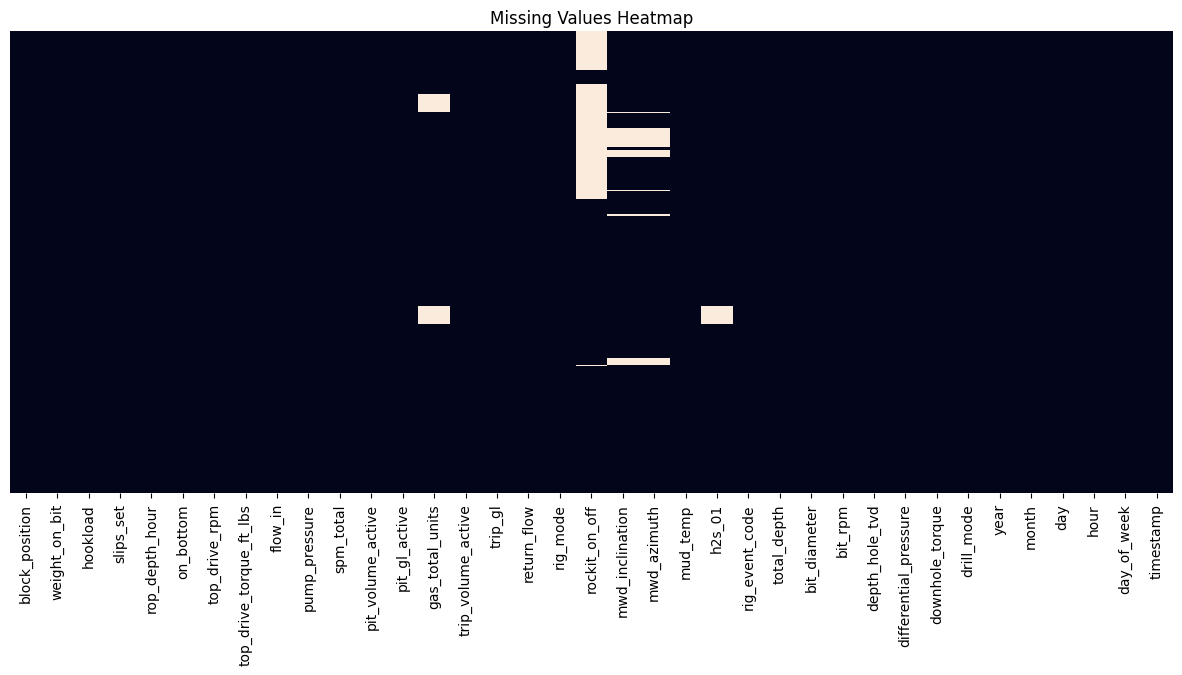

In [41]:
plt.figure(figsize=(15,6))

sns.heatmap(df.isnull(),
            cbar=False,
            yticklabels=False)

plt.title("Missing Values Heatmap")
plt.show()

## 5. Duplicate Record Analysis

Duplicate records are identified and removed to ensure data consistency and prevent bias during model training.

In [42]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :",duplicates)

Duplicate Rows : 0


In [43]:
df.drop_duplicates(inplace=True)

print("Dataset Shape :",df.shape)

Dataset Shape : (598709, 37)


## 6. Replace Invalid Values

The drilling dataset contains placeholder values such as **-999.25**, **-9999**, and **9999** to indicate unavailable or invalid sensor readings. These values do not represent actual measurements and can negatively affect statistical analysis and machine learning models if treated as valid data.

Therefore, these placeholder values are replaced with **NaN (Not a Number)**, allowing them to be identified as missing values and handled appropriately during the data imputation stage.

In [44]:
invalid_values = [-999.25,-9999,9999]

df.replace(invalid_values,np.nan,inplace=True)

In [45]:
df.isnull().sum().sort_values(ascending=False)

,0
rockit_on_off,199513
mwd_azimuth,51618
mwd_inclination,51613
gas_total_units,46269
h2s_01,23231
slips_set,65
mud_temp,46
top_drive_torque_ft_lbs,45
block_position,45
drill_mode,45


## 7. Data Type Conversion

Columns are converted into appropriate data types. Time is converted to datetime format, while categorical variables are stored using the category data type.

In [47]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [ ]:
categorical_columns = [
    "rig_mode",
    "drill_mode",
    "rockit_on_off",
    "slips_set",
    "on_bottom"
]

for col in categorical_columns:
    if col in df.columns:
        df[col] = df[col].astype("category")

## 8. Missing Value Treatment

Remaining missing values are handled using appropriate statistical techniques such as median imputation for numerical variables and mode imputation for categorical variables.

In [ ]:
missing_percentage = (df.isnull().sum()/len(df))*100

missing_percentage.sort_values(ascending=False)

rss_azimuth                87.477992
mwd_gamma_api              87.367392
res_ps_2mhz_18in           87.367225
res_ps_400khz_18in         87.367225
h2s_01                     50.489124
pit_gl_active              48.093557
rockit_on_off              33.701335
downhole_torque            15.936798
rig_mode                   13.173118
rig_event_code             13.173118
bit_rpm                    12.558652
bit_diameter               11.234278
mwd_azimuth                 8.798069
mwd_inclination             8.797236
gas_total_units             7.902938
hookload                    0.586649
slips_set                   0.586149
block_position              0.584983
top_drive_torque_ft_lbs     0.583151
top_drive_rpm               0.583151
return_flow                 0.583151
differential_pressure       0.582818
drill_mode                  0.582818
on_bottom                   0.582651
rop_depth_hour              0.582651
weight_on_bit               0.582651
pump_pressure               0.582318
t

In [49]:
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

print(missing_percentage)

rockit_on_off              33.323869
mwd_azimuth                 8.621551
mwd_inclination             8.620716
gas_total_units             7.728128
h2s_01                      3.880182
slips_set                   0.010857
mud_temp                    0.007683
top_drive_torque_ft_lbs     0.007516
block_position              0.007516
drill_mode                  0.007516
differential_pressure       0.007516
on_bottom                   0.007349
rig_mode                    0.004677
rig_event_code              0.004677
rop_depth_hour              0.000000
weight_on_bit               0.000000
hookload                    0.000000
pit_gl_active               0.000000
pit_volume_active           0.000000
spm_total                   0.000000
top_drive_rpm               0.000000
trip_gl                     0.000000
trip_volume_active          0.000000
return_flow                 0.000000
flow_in                     0.000000
pump_pressure               0.000000
total_depth                 0.000000
b

In [50]:
threshold = 30

drop_cols = missing_percentage[
    missing_percentage > threshold
].index

print(drop_cols)

Index(['rockit_on_off'], dtype='object')


In [51]:
df.drop(columns=drop_cols,
        inplace=True)

print(df.shape)

(598709, 36)


## Missing Value Treatment

Handle Remaining Missing Values

In [52]:
numeric_cols = df.select_dtypes(include=np.number).columns

In [53]:
for col in numeric_cols:
    df[col].fillna(df[col].median(),inplace=True)

In [54]:
cat_cols = df.select_dtypes(include="category").columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0],inplace=True)    

In [55]:
df.isnull().sum().sort_values(ascending=False)

,0
block_position,0
weight_on_bit,0
hookload,0
slips_set,0
rop_depth_hour,0
on_bottom,0
top_drive_rpm,0
top_drive_torque_ft_lbs,0
flow_in,0
pump_pressure,0


## 9. Outlier Detection

Outliers are detected using the Interquartile Range (IQR) method. Extreme values are capped to reduce their influence while preserving useful information.

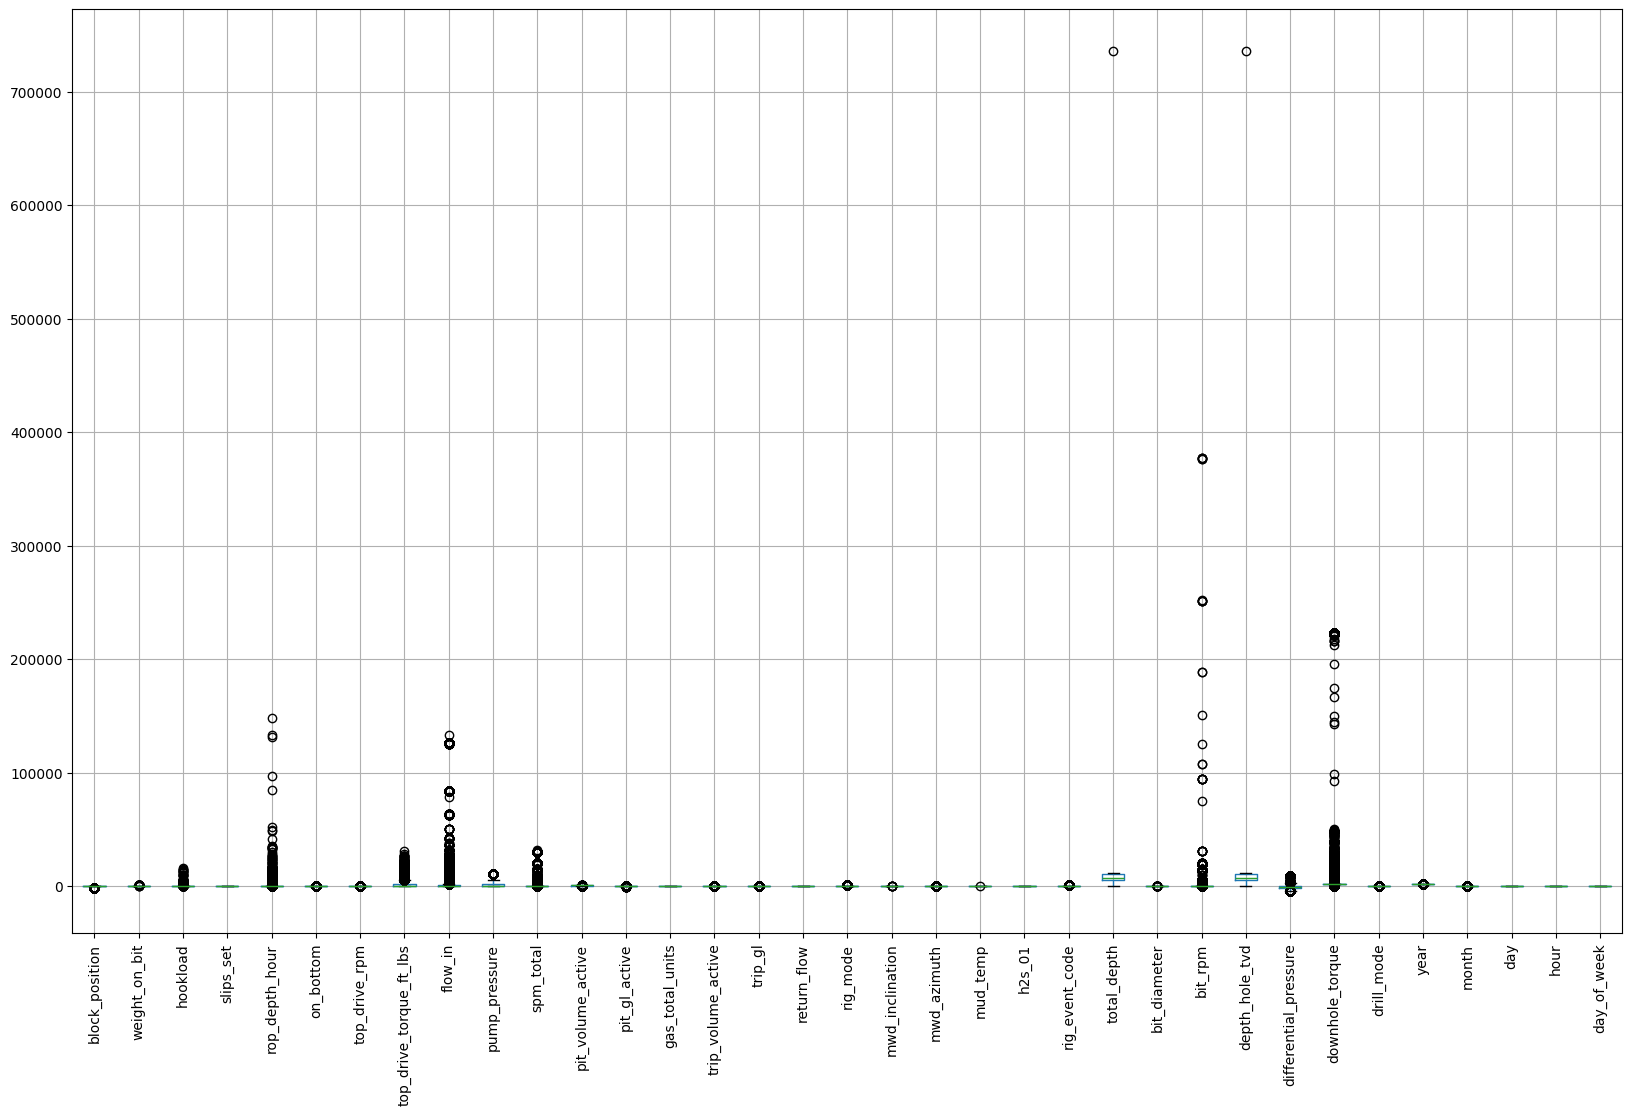

In [56]:
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(20,12))

df[numeric_cols].boxplot(rot=90)

plt.show()

In [57]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

In [58]:
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df[numeric_cols] = df[numeric_cols].clip(lower,upper,axis=1)

## 10. Feature Engineering

New time-based features such as year, month, day, hour, and day of the week are extracted to improve the predictive capability of machine learning models.

In [60]:
# Handle timestamp column
if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Create time features only if they don't already exist
    if "year" not in df.columns:
        df["year"] = df["timestamp"].dt.year

    if "month" not in df.columns:
        df["month"] = df["timestamp"].dt.month

    if "day" not in df.columns:
        df["day"] = df["timestamp"].dt.day

    if "hour" not in df.columns:
        df["hour"] = df["timestamp"].dt.hour

    if "day_of_week" not in df.columns:
        df["day_of_week"] = df["timestamp"].dt.dayofweek

else:
    raise KeyError("No timestamp column found in the dataset.")

print("Timestamp preprocessing complete.")
print(df[["timestamp", "year", "month", "day", "hour", "day_of_week"]].head())

Timestamp preprocessing complete.
            timestamp  year  month  day  hour  day_of_week
0 2020-10-25 12:00:00  2020   10.0   25    12            6
1 2020-10-25 12:00:00  2020   10.0   25    12            6
2 2020-10-25 12:00:00  2020   10.0   25    12            6
3 2020-10-25 12:00:00  2020   10.0   25    12            6
4 2020-10-25 12:00:00  2020   10.0   25    12            6


## 11. Final Dataset Validation

The cleaned dataset is validated to ensure there are no duplicate records, data types are correct, and missing values have been appropriately handled.

In [61]:
print("="*60)

print("FINAL DATASET")

print("="*60)

print(df.shape)

print()

print(df.info())

FINAL DATASET
(598709, 36)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598709 entries, 0 to 598708
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   block_position           598709 non-null  float64       
 1   weight_on_bit            598709 non-null  float64       
 2   hookload                 598709 non-null  float64       
 3   slips_set                598709 non-null  float64       
 4   rop_depth_hour           598709 non-null  float64       
 5   on_bottom                598709 non-null  float64       
 6   top_drive_rpm            598709 non-null  float64       
 7   top_drive_torque_ft_lbs  598709 non-null  float64       
 8   flow_in                  598709 non-null  float64       
 9   pump_pressure            598709 non-null  float64       
 10  spm_total                598709 non-null  float64       
 11  pit_volume_active        598709 non-null  float64 

In [62]:
print(df.isnull().sum().sum())

0


In [63]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing = missing[missing["Missing Values"] > 0]
missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage


In [64]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [65]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [66]:
print(df.isnull().sum().sum())

0


## 12. Export Cleaned Dataset

The final cleaned dataset is exported as a CSV file. This dataset will be used in the subsequent exploratory data analysis and machine learning notebooks.

In [67]:
df.to_csv(
    "cleaned_drilling_data.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


# Conclusion

The raw drilling dataset has been successfully cleaned and preprocessed. Missing values, duplicates, invalid entries, and outliers have been addressed, and additional features have been engineered. The resulting dataset is now suitable for exploratory data analysis, machine learning model development, and visualization in Power BI.